# First plotting attempt of example data

In [1]:
#import packages
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import inspect
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point

#### define input and outputs

In [2]:
#inputs
#input data
input_file_path = '../01_data/01_input_data/02_processed/'

#original network
original_network_file = 'input_network_data.xlsx'

#outputs

#get path
current_folder_path = os.getcwd()
parent_folder_path = os.path.abspath(os.path.join(current_folder_path, os.pardir))

# Specify the subfolder name
output_folder = '/02_plots/'

#create path to correct folder
images_folder_path = parent_folder_path + output_folder

#replace \ by correct one:/
images_folder_path = images_folder_path.replace("\\", "/")

#### read in the data

In [73]:
original_network_df = pd.read_excel(input_file_path + original_network_file)
original_network_df

,source,target,capacity,source_name,target_name
0,"(757926.5454303586, 7207322.22114858)","(807807.6960599166, 7159118.912010687)",27.809143,node_0001,node_0002
1,"(757926.5454303586, 7207322.22114858)","(807807.6960599166, 7159118.912010687)",27.809143,node_0001,node_0002
2,"(807807.6960599166, 7159118.912010687)","(815843.850100283, 7134574.8782972265)",65.753400,node_0002,node_0362
3,"(681661.3396489053, 6764564.505472038)","(637008.0862654719, 6772214.151799204)",27.809143,node_0003,node_0004
4,"(681661.3396489053, 6764564.505472038)","(682552.0068947424, 6728692.507370236)",6.329657,node_0003,node_0196
...,...,...,...,...,...
1015,"(1578045.0639771034, 7151621.849673391)","(1596573.6366221898, 7137478.869636691)",2.000000,node_0377,node_0656
1016,"(1067619.5952070616, 6021525.093097464)","(1068770.638741864, 6030297.861735745)",2.234585,node_0378,node_0611
1017,"(781423.8635470029, 6822588.252173902)","(710902.966129464, 6885968.896764138)",27.650787,node_0379,node_0657
1018,"(830186.2532940885, 7111961.970883027)","(274855.1698549848, 8006943.521699804)",27.809143,node_0380,node_0658


In [84]:
# Extract unique nodes and their coordinates
# Create separate dataframes for source nodes and target nodes
source_nodes = original_network_df[['source_name', 'source']].drop_duplicates().reset_index(drop=True)
target_nodes = original_network_df[['target_name', 'target']].drop_duplicates().reset_index(drop=True)

# Rename columns for clarity
source_nodes.columns = ['node_name', 'coordinates']
target_nodes.columns = ['node_name', 'coordinates']

# Concatenate the two dataframes for the nodes and coordinates dataframe
unique_nodes = pd.concat([source_nodes, target_nodes]).drop_duplicates().reset_index(drop=True)

#create an edges dataframe
edges_original_network_df = original_network_df[['source_name', 'target_name']]
# Assuming 'df' is your existing data frame

# New column data that all pipes exist
new_column_data = 'existing'

# Specify the index where you want to insert the new column (2 in this example)
index_to_insert = 2

# Use the insert method to add a new column named 'type' at the specified index
edges_original_network_df.insert(index_to_insert, 'type', new_column_data)

In [5]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes with coordinates (to have a better illustration)
nodes = {
    'S1': (0, 1),
    'S2': (0, 0),
    'S3': (0, -1),
    'D1': (1, 1),
    'D2': (1, 0),
    'D3': (1, -1),
    'D4': (2, 0),
    'D5': (3, 1),
    'D6': (3, -1),
    'D7': (4, -1),
    'D8': (4, 1),
    'D9': (5, 1),
    'D10': (5, -1),
}

G.add_nodes_from(nodes)

# Add edges from the table with edge types from methane
edges_methane = [
    ('S1', 'D1', {'type': 'existing'}),
    ('S1', 'D2', {'type': 'existing'}),
    ('S2', 'D2', {'type': 'existing'}),
    ('S2', 'D3', {'type': 'new'}),
    ('S3', 'D1', {'type': 'existing'}),
    ('D1', 'D2', {'type': 'existing'}),
    ('D3', 'D4', {'type': 'new'}),
    ('D4', 'D5', {'type': 'new'}),
    ('D4', 'D6', {'type': 'existing'}),
    ('D6', 'D7', {'type': 'existing'}),
    ('D5', 'D8', {'type': 'existing'}),
    ('D5', 'D9', {'type': 'existing'}),
    ('D9', 'D10', {'type': 'existing'}),
    ('D7', 'D10', {'type': 'existing'}),
]

#hydrogen grid edges
edges_hy = [
    ('S1', 'D2', {'type': 'new'}),
    ('S2', 'D3', {'type': 'converted'}),
    ('S3', 'D1', {'type': 'new'}),
    ('D3', 'D4', {'type': 'converted'}),
    ('D4', 'D5', {'type': 'converted'}),
    ('D4', 'D6', {'type': 'new'}),
    ('D6', 'D7', {'type': 'new'}),
    ('D5', 'D8', {'type': 'new'}),
    ('D5', 'D9', {'type': 'new'}),
    ('D9', 'D10', {'type': 'new'}),
]

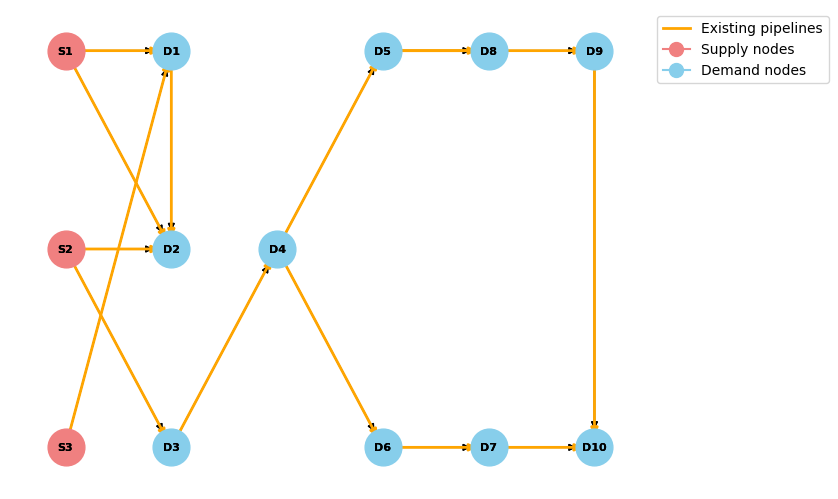

In [14]:
#plot original methane grid

# Add edges from the table with edge types from methane
edges_origin = [
    ('S1', 'D1', {'type': 'existing'}),
    ('S1', 'D2', {'type': 'existing'}),
    ('S2', 'D2', {'type': 'existing'}),
    ('S2', 'D3', {'type': 'existing'}),
    ('S3', 'D1', {'type': 'existing'}),
    ('D1', 'D2', {'type': 'existing'}),
    ('D3', 'D4', {'type': 'existing'}),
    ('D4', 'D5', {'type': 'existing'}),
    ('D4', 'D6', {'type': 'existing'}),
    ('D6', 'D7', {'type': 'existing'}),
    ('D5', 'D8', {'type': 'existing'}),
    ('D5', 'D9', {'type': 'existing'}),
    ('D9', 'D10', {'type': 'existing'}),
    ('D7', 'D10', {'type': 'existing'}),
]

# Separate nodes with 'S' in their names and others
s_nodes = [node for node in G.nodes if 'S' in node]
other_nodes = [node for node in G.nodes if 'S' not in node]

#plot methane grid
G.add_edges_from(edges_origin)

# Separate edges by type
new_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'new']
existing_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'existing']

# Plot the graph with node coordinates and different colors for edge types
pos = nodes
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=s_nodes, node_color='lightcoral', label='Supply nodes')
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G, pos, edgelist=new_edges, edge_color='green', label='New edges', width=2)
nx.draw_networkx_edges(G, pos, edgelist=existing_edges, edge_color='orange', label='Existing edges', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Existing pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

#output_filepath = os.path.join(output_folder, 'network_methane_plot.png')
plt.savefig(images_folder_path + 'network_origin_plot.png', bbox_inches='tight')


# Display the plot
plt.show()

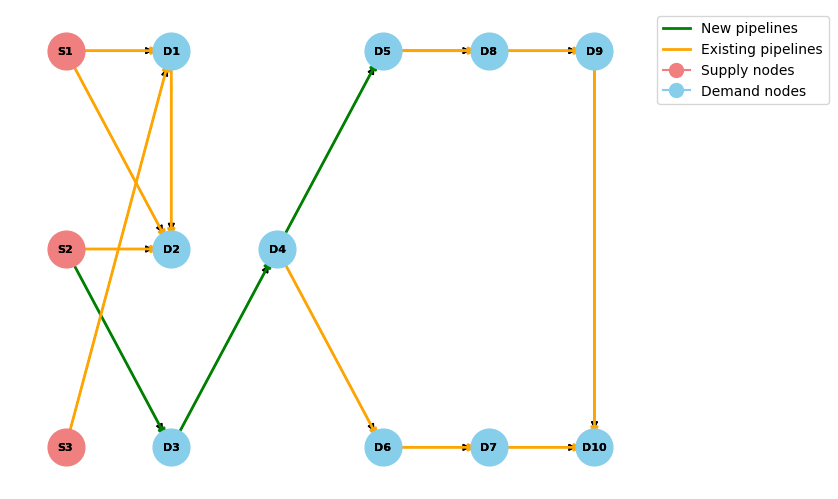

In [95]:
#plot methane grid
G.add_edges_from(edges_methane)

# Separate edges by type
new_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'new']
existing_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'existing']

# Plot the graph with node coordinates and different colors for edge types
pos = nodes
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=s_nodes, node_color='lightcoral', label='Supply nodes')
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G, pos, edgelist=new_edges, edge_color='green', label='New edges', width=2)
nx.draw_networkx_edges(G, pos, edgelist=existing_edges, edge_color='orange', label='Existing edges', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='New pipelines'),
    Line2D([0], [0], color='orange', lw=2, label='Existing pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

#output_filepath = os.path.join(output_folder, 'network_methane_plot.png')
plt.savefig(images_folder_path + 'network_methane_plot.png', bbox_inches='tight')


# Display the plot
plt.show()

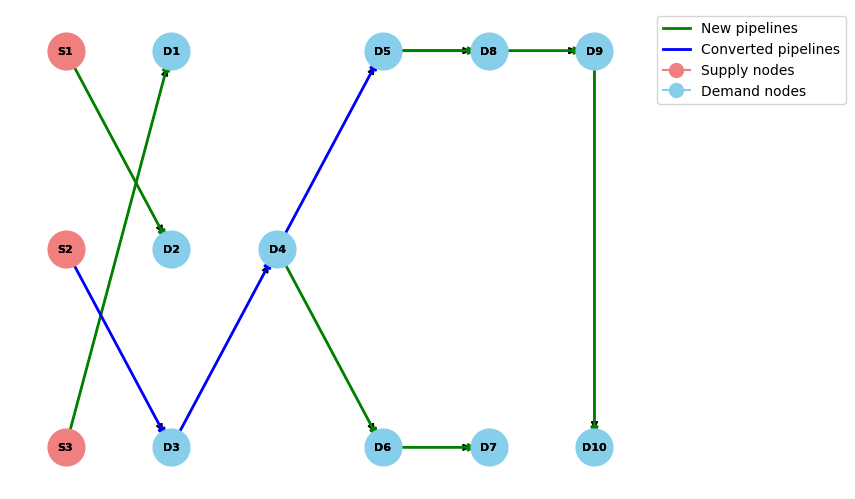

In [74]:
#plot hydrogen grid

G_hydrogen = nx.DiGraph()

G_hydrogen.add_edges_from(edges_hy)

# Separate edges by type
new_edges = [(u, v) for u, v, d in G_hydrogen.edges(data=True) if d['type'] == 'new']
converted_edges = [(u, v) for u, v, d in G_hydrogen.edges(data=True) if d['type'] == 'converted']

# Plot the graph with node coordinates and different colors for edge types
pos = nodes
nx.draw(G_hydrogen, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=s_nodes, node_color='lightcoral', label='Supply nodes')
nx.draw(G_hydrogen, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G_hydrogen, pos, edgelist=new_edges, edge_color='green', label='New edges', width=2)
nx.draw_networkx_edges(G_hydrogen, pos, edgelist=converted_edges, edge_color='blue', label='Existing edges', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='New pipelines'),
    Line2D([0], [0], color='blue', lw=2, label='Converted pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.savefig(images_folder_path + 'network_hydrogen_plot.png', bbox_inches='tight')

# Display the plot
plt.show()

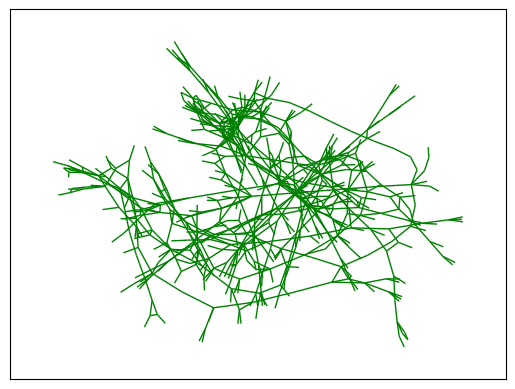

In [79]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy

# Your node dataframe
node_data = pd.DataFrame({
    'node_name': ['node_0001', 'node_0002', 'node_0003', 'node_0004'],
    'coordinates': [(757926.5454303586, 7207322.22114858),
                    (807807.6960599166, 7159118.912010687),
                    (681661.3396489053, 6764564.505472038),
                    (781661.3396489053, 6864564.505472038)]
})

node_data = unique_nodes

# Your edge dataframe
edge_data = pd.DataFrame({
    'source_name': ['node_0001', 'node_0001', 'node_0002', 'node_0002', 'node_0002', 'node_0002'],
    'target_name': ['node_0002', 'node_0002', 'node_0003', 'node_0003', 'node_0003', 'node_0003'],
    'type': ['existing', 'existing', 'existing','existing', 'existing', 'existing']
})

# Remove duplicates based on 'source_name' and 'target_name'
edges_original_network_df = edges_original_network_df.drop_duplicates(subset=['source_name', 'target_name'])

edge_data = edges_original_network_df

# Create a graph
G = nx.Graph()

# Add nodes with positions
for _, row in unique_nodes.iterrows():
    node_name = row['node_name']
    coordinates = row['coordinates']
    G.add_node(node_name, pos=coordinates)

# Add edges
for _, row in edge_data.iterrows():
    source_name = row['source_name']
    target_name = row['target_name']
    G.add_edge(source_name, target_name, edge_type=row['type'])

# Get node positions using a layout algorithm (spring_layout in this case)
pos = nx.spring_layout(G)

# Draw nodes (subsample 100 nodes for better visualization)
subsample_nodes = list(G.nodes())[:100]
#nx.draw_networkx_nodes(G, pos, nodelist=subsample_nodes, node_size=200, node_color='skyblue', alpha=0.7)

# Draw edges with different colors for different edge types
edge_colors = ['g' if G[source][target]['edge_type'] == 'existing' else 'r' for source, target in G.edges()]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors)

# Draw labels (subsample 100 nodes for better visualization)
subsample_labels = {node: node for node in subsample_nodes}
#nx.draw_networkx_labels(G, pos, labels=subsample_labels)

# Display the plot
plt.show()
